# Single Image Haze Removal Using Dark Channel Prior
This notebook implements the Dark Channel Prior (DCP) algorithm for image dehazing, based on the paper by Kaiming He et al. and the C++ implementation:
https://github.com/ZQPei/Haze_Removal_cpp


## Phase1

In [1]:
import kagglehub
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

In [2]:
# config
NUM_IMAGES = 10

In [3]:
### Dark Channel Prior ###

def get_dark_channel(img, window_size=15):
    b, g, r = cv2.split(img)
    min_img = cv2.min(r, cv2.min(g, b))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (window_size, window_size))
    dark_channel = cv2.erode(min_img, kernel)
    return dark_channel

def get_atmosphere_light(img, dark_channel):
    h, w = img.shape[:2]
    num_pixels = h * w
    num_top_pixels = int(max(num_pixels * 0.001, 1))

    dark_vec = dark_channel.reshape(-1)
    img_vec = img.reshape(-1, 3)

    indices = np.argsort(dark_vec)[::-1] # descending order
    top_indices = indices[:num_top_pixels]
    
    top_pixels = img_vec[top_indices]
    A = np.mean(top_pixels, axis=0)
    return A

def get_transmission(img, A, window_size=15, omega=0.95):
    # Normalize image by atmosphere light
    norm_img = np.empty_like(img, dtype=np.float64)
    for i in range(3):
        norm_img[:,:,i] = img[:,:,i] / A[i]
    
    transmission = 1 - omega * get_dark_channel(norm_img, window_size)
    return transmission

def refine_transmission(img, transmission, radius=60, eps=0.001):
    # Use Guided Filter from OpenCV's extended image processing module
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray = np.float32(gray) / 255.0
        # cv2.ximgproc.guidedFilter(guide, src, radius, eps)
        refined_t = cv2.ximgproc.guidedFilter(guide=gray, src=np.float32(transmission), radius=radius, eps=eps)
    except AttributeError:
        print("cv2.ximgproc not found. Using unrefined transmission.")
        refined_t = transmission
    return refined_t

def recover_radiance(img, transmission, A, t0=0.1):
    # J = (I - A)/max(t, t0) + A
    t = cv2.max(transmission, t0)
    J = np.empty_like(img, dtype=np.float64)
    for i in range(3):
        J[:,:,i] = (img[:,:,i] - A[i]) / t + A[i]
    return np.clip(J, 0, 255).astype(np.uint8)

def dehaze(img, window_size=15, omega=0.95, radius=60, eps=0.001, t0=0.1):
    I = np.float64(img)
    dark_channel = get_dark_channel(I, window_size)
    A = get_atmosphere_light(I, dark_channel)
    transmission = get_transmission(I, A, window_size, omega)
    refined_t = refine_transmission(img, transmission, radius, eps)
    J = recover_radiance(I, refined_t, A, t0)
    return J, dark_channel, refined_t, A


GT  : C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\GT\0001_0.8_0.2.jpg
Hazy: C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\hazy\0001_0.8_0.2.jpg
cv2.ximgproc not found. Using unrefined transmission.
PSNR/SSIM (Hazy   vs GT): 16.28 dB / 0.8449
PSNR/SSIM (Dehaze vs GT): 19.27 dB / 0.8495


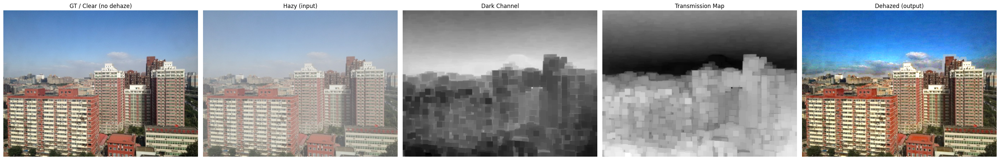

GT  : C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\GT\0002_0.8_0.08.jpg
Hazy: C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\hazy\0002_0.8_0.08.jpg
cv2.ximgproc not found. Using unrefined transmission.
PSNR/SSIM (Hazy   vs GT): 20.37 dB / 0.9153
PSNR/SSIM (Dehaze vs GT): 14.13 dB / 0.7030


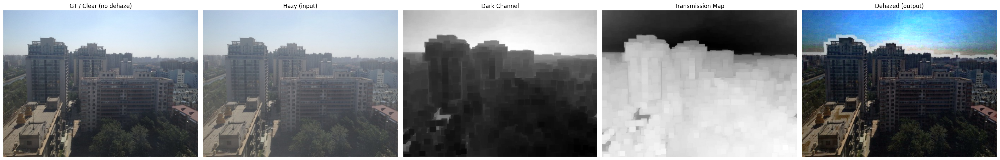

GT  : C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\GT\0003_0.8_0.2.jpg
Hazy: C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\hazy\0003_0.8_0.2.jpg
cv2.ximgproc not found. Using unrefined transmission.
PSNR/SSIM (Hazy   vs GT): 17.43 dB / 0.9100
PSNR/SSIM (Dehaze vs GT): 16.71 dB / 0.7615


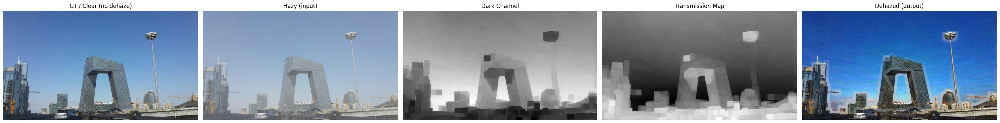

GT  : C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\GT\0004_0.9_0.12.jpg
Hazy: C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\hazy\0004_0.9_0.12.jpg
cv2.ximgproc not found. Using unrefined transmission.
PSNR/SSIM (Hazy   vs GT): 22.48 dB / 0.9430
PSNR/SSIM (Dehaze vs GT): 12.38 dB / 0.7713


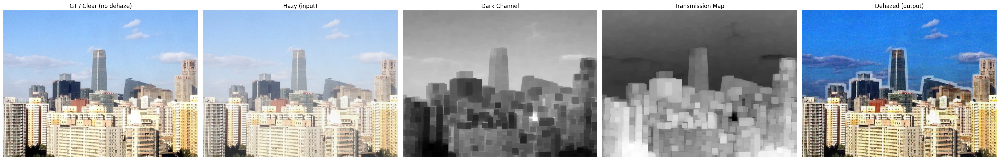

GT  : C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\GT\0006_0.85_0.08.jpg
Hazy: C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\hazy\0006_0.85_0.08.jpg
cv2.ximgproc not found. Using unrefined transmission.
PSNR/SSIM (Hazy   vs GT): 20.07 dB / 0.8982
PSNR/SSIM (Dehaze vs GT): 14.29 dB / 0.7879


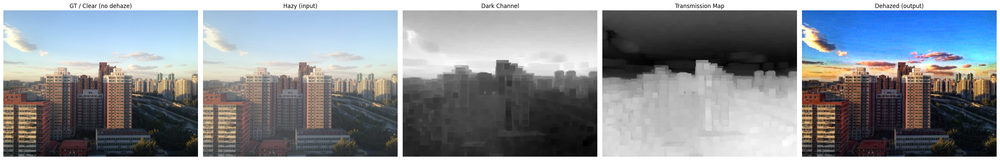

GT  : C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\GT\0007_0.9_0.16.jpg
Hazy: C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\hazy\0007_0.9_0.16.jpg
cv2.ximgproc not found. Using unrefined transmission.
PSNR/SSIM (Hazy   vs GT): 12.81 dB / 0.7535
PSNR/SSIM (Dehaze vs GT): 15.86 dB / 0.7701


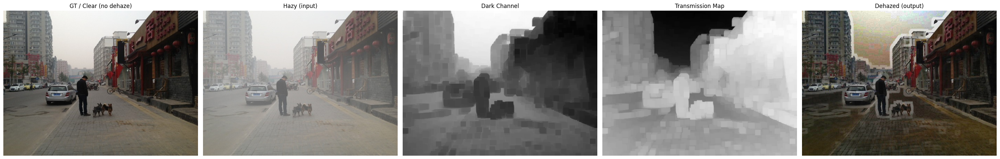

GT  : C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\GT\0009_0.8_0.16.jpg
Hazy: C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\hazy\0009_0.8_0.16.jpg
cv2.ximgproc not found. Using unrefined transmission.
PSNR/SSIM (Hazy   vs GT): 14.12 dB / 0.7735
PSNR/SSIM (Dehaze vs GT): 16.49 dB / 0.7906


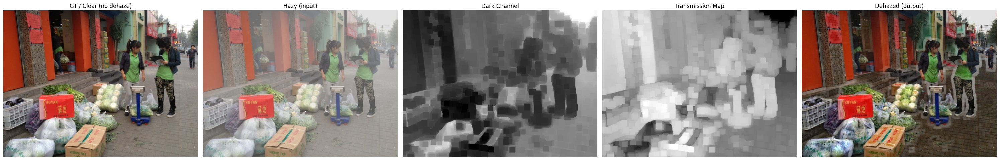

GT  : C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\GT\0010_0.95_0.16.jpg
Hazy: C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\hazy\0010_0.95_0.16.jpg
cv2.ximgproc not found. Using unrefined transmission.
PSNR/SSIM (Hazy   vs GT): 10.00 dB / 0.6119
PSNR/SSIM (Dehaze vs GT): 18.66 dB / 0.8177


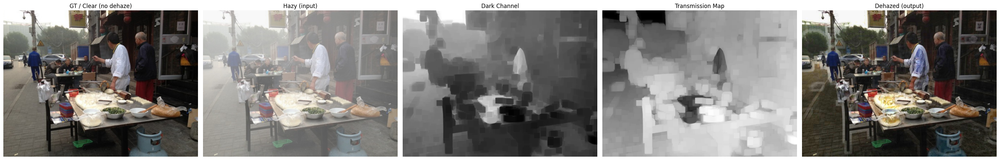

GT  : C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\GT\0011_0.95_0.16.jpg
Hazy: C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\hazy\0011_0.95_0.16.jpg
cv2.ximgproc not found. Using unrefined transmission.
PSNR/SSIM (Hazy   vs GT): 11.71 dB / 0.6327
PSNR/SSIM (Dehaze vs GT): 17.23 dB / 0.8160


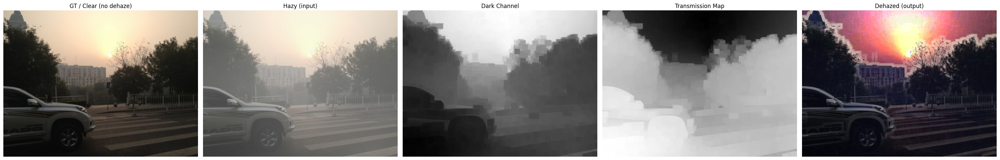

GT  : C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\GT\0014_0.8_0.12.jpg
Hazy: C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K\test\hazy\0014_0.8_0.12.jpg
cv2.ximgproc not found. Using unrefined transmission.
PSNR/SSIM (Hazy   vs GT): 16.92 dB / 0.8817
PSNR/SSIM (Dehaze vs GT): 13.62 dB / 0.6719


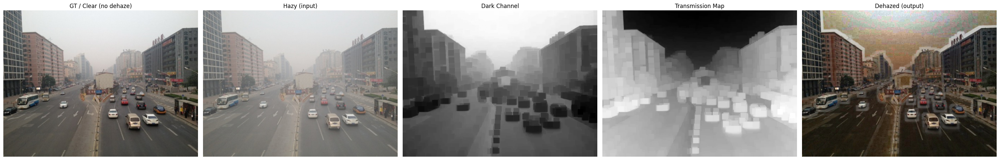

In [4]:
def _ensure_same_shape(ref: np.ndarray, img: np.ndarray) -> np.ndarray:
    """Resize `img` to match `ref` if shapes differ (keeps channel count)."""
    if ref.shape == img.shape:
        return img
    ref_h, ref_w = ref.shape[:2]
    img_h, img_w = img.shape[:2]
    if img_h == 0 or img_w == 0:
        raise ValueError("Input image has invalid shape")
    interp = cv2.INTER_AREA if (img_h > ref_h or img_w > ref_w) else cv2.INTER_CUBIC
    if img.ndim == 2:
        return cv2.resize(img, (ref_w, ref_h), interpolation=interp)
    return cv2.resize(img, (ref_w, ref_h), interpolation=interp)

def compute_psnr_ssim(img_ref: np.ndarray, img_test: np.ndarray, *, data_range: float = 255.0) -> tuple[float, float]:
    """Compute PSNR (dB) and SSIM between two images.

    Assumes both images use the same color order (e.g., both are BGR as loaded by OpenCV).
    """
    if img_ref is None or img_test is None:
        raise ValueError("img_ref/img_test is None")
    if img_ref.ndim != img_test.ndim:
        raise ValueError(f"Dimension mismatch: ref.ndim={img_ref.ndim}, test.ndim={img_test.ndim}")
    img_test = _ensure_same_shape(img_ref, img_test)
    ref = img_ref.astype(np.float64, copy=False)
    test = img_test.astype(np.float64, copy=False)
    psnr = float(peak_signal_noise_ratio(ref, test, data_range=data_range))
    h, w = ref.shape[:2]
    win_size = 7
    if min(h, w) < win_size:
        win_size = max(3, (min(h, w) // 2) * 2 - 1)  # odd, >=3
    if ref.ndim == 2:
        ssim = float(structural_similarity(ref, test, data_range=data_range, win_size=win_size))
    else:
        ssim = float(structural_similarity(ref, test, data_range=data_range, channel_axis=-1, win_size=win_size))
    return psnr, ssim

# download dataset
path = kagglehub.dataset_download("kmljts/reside-6k")
root = Path(path)

test_dir = root / "RESIDE-6K" / "test" if (root / "RESIDE-6K").exists() else root / "test"

gt_dir = test_dir / "GT"
hazy_dir = test_dir / "hazy"

gt_images = sorted(list(gt_dir.rglob("*.jpg")) + list(gt_dir.rglob("*.png")))
hazy_images = sorted(list(hazy_dir.rglob("*.jpg")) + list(hazy_dir.rglob("*.png")))

indices = range(NUM_IMAGES)
metrics_rows: list[dict] = []
for idx in indices:
    if not gt_images:
        raise RuntimeError(f"No GT images found in: {gt_dir}")
    if not hazy_images:
        raise RuntimeError(f"No hazy images found in: {hazy_dir}")

    gt_path = gt_images[idx]
    key = gt_path.stem 

    # find hazy image: e.g. 0001_0.8_0.2.jpg
    matches = [p for p in hazy_images if p.stem.startswith(key + "_")]
    hazy_path = matches[0] if matches else hazy_images[idx]

    print("GT  :", gt_path)
    print("Hazy:", hazy_path)

    gt_img = cv2.imread(str(gt_path))
    hazy_img = cv2.imread(str(hazy_path))
    if gt_img is None or hazy_img is None:
        raise RuntimeError("Failed to read GT/hazy image (cv2.imread returned None)")

    J, dark, t, A = dehaze(hazy_img)

    # Metrics
    psnr_hazy, ssim_hazy = compute_psnr_ssim(gt_img, hazy_img)
    psnr_out, ssim_out = compute_psnr_ssim(gt_img, J)
    print(f"PSNR/SSIM (Hazy   vs GT): {psnr_hazy:.2f} dB / {ssim_hazy:.4f}")
    print(f"PSNR/SSIM (Dehaze vs GT): {psnr_out:.2f} dB / {ssim_out:.4f}")

    metrics_rows.append({
        "idx": idx,
        "gt": gt_path.name,
        "hazy": hazy_path.name,
        "psnr_hazy": psnr_hazy,
        "ssim_hazy": ssim_hazy,
        "psnr_dehaze": psnr_out,
        "ssim_dehaze": ssim_out,
    })

    # Visualization
    plt.figure(figsize=(30, 6))

    plt.subplot(1, 5, 1)
    plt.imshow(cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB))
    plt.title("GT / Clear (no dehaze)")
    plt.axis("off")

    plt.subplot(1, 5, 2)
    plt.imshow(cv2.cvtColor(hazy_img, cv2.COLOR_BGR2RGB))
    plt.title("Hazy (input)")
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.imshow(dark, cmap='gray')
    plt.title('Dark Channel')
    plt.axis('off')

    plt.subplot(1, 5, 4)
    plt.imshow(t, cmap='gray')
    plt.title('Transmission Map')
    plt.axis('off')

    plt.subplot(1, 5, 5)
    plt.imshow(cv2.cvtColor(J, cv2.COLOR_BGR2RGB))
    plt.title("Dehazed (output)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [5]:
# metrics summary (run after the loop cell)
import pandas as pd

if "metrics_rows" not in globals() or not metrics_rows:
    raise RuntimeError("No metrics found. Run the previous cell first.")

df = pd.DataFrame(metrics_rows)
display(df[["idx", "gt", "psnr_hazy", "ssim_hazy", "psnr_dehaze", "ssim_dehaze"]])

print("\nMean metrics (over shown samples):")
print(df[["psnr_hazy", "ssim_hazy", "psnr_dehaze", "ssim_dehaze"]].mean(numeric_only=True))

,idx,gt,psnr_hazy,ssim_hazy,psnr_dehaze,ssim_dehaze
0,0,0001_0.8_0.2.jpg,16.278487,0.844895,19.271696,0.849455
1,1,0002_0.8_0.08.jpg,20.365196,0.915329,14.126015,0.702992
2,2,0003_0.8_0.2.jpg,17.425225,0.910031,16.707172,0.761492
3,3,0004_0.9_0.12.jpg,22.482107,0.943013,12.381807,0.771311
4,4,0006_0.85_0.08.jpg,20.068372,0.898196,14.293978,0.787880
5,5,0007_0.9_0.16.jpg,12.814936,0.753511,15.858659,0.770053
6,6,0009_0.8_0.16.jpg,14.119970,0.773504,16.492972,0.790555
7,7,0010_0.95_0.16.jpg,9.997204,0.611878,18.660042,0.817678
8,8,0011_0.95_0.16.jpg,11.711760,0.632715,17.225798,0.815974
9,9,0014_0.8_0.12.jpg,16.918415,0.881726,13.619615,0.671947



Mean metrics (over shown samples):
psnr_hazy      16.218167
ssim_hazy       0.816480
psnr_dehaze    15.863775
ssim_dehaze     0.773934
dtype: float64


## Phase2